# T52 — Andean Frontal-Cordillera thermochronology on paleo-Earth: directly above an active convergent margin

**Cluster F: paleo-geography and paleo-topography.**

*Based on:* Howlett, C. et al. (2025), *Tectonics* 44, e2024TC008433. *Miocene construction of the High Andes recorded by exhumation of the Frontal Cordillera, La Ramada Massif of western Argentina (32°S)* — Howlett et al.'s Fig. 9 multi-publication thermochronology compilation, archived on Zenodo (DOI 10.5281/zenodo.11152585, CC-BY 4.0).

## What this notebook does

Pedagogical pair to T51: where the Afro-Arabia samples are located deep in the continental interior far from any active subduction (cooling × convergence correlation expected to be weak), the Frontal Cordillera samples are located **directly above** the active Nazca → South America subduction zone. The cooling-rate vs convergence-rate signal should be much stronger here than for AARS — and the time-series Pearson r should reflect that.

### Data format note — different from T51

T51 (Boone et al. 2025 EarthBank export) ships **per-window TempDiff cooling rates** (°C/Myr) derived from full QTQt time-temperature paths. T52 instead works with the **Howlett 2025 Fig 9 compilation**: ~577 samples from many publications, each with a single low-temperature thermochronological closure age (AHe / AFT / ZHe / ZFT). The per-sample heat-loss proxy is therefore a **lifetime-average cooling rate**:

$$\dot{T}_\text{lifetime} = \frac{T_\text{closure} - T_\text{surface}}{\text{closure age}}$$

computed using method-specific nominal closure temperatures (AHe 70°C, AFT 110°C, ZHe 180°C, ZFT 240°C) and a 10°C nominal surface temperature. At a snapshot age `t_snap`, the panels show samples actively crossing their closure isotherm at `t_snap` (i.e. with `|closure_age - t_snap| < window`), coloured by lifetime-average cooling rate.

**Sections** (same shape as T51 for direct comparison):
1. **§1** Load plate model + Howlett 2025 Fig 9 compilation.
2. **§2** Per-sample cooling rate at the snapshot age + reconstruction.
3. **§3** Layer A — cooling rates × seafloor age (global orthographic centred on South America).
4. **§4** Layer B — cooling rates × paleotopography (regional Andean zoom, Scotese & Wright corrected DEM, SW-reconstructed samples).
5. **§5** Layer C — cooling rates × convergence rate (Nazca → South America subduction).
6. **§6** Cross-variable correlations — Pearson r per age, time-series.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~2 min for a single snapshot; ~5 min for the time-series sweep at 5-Myr cadence.

## Data availability

**Howlett, C., Carrapa, B., Reiners, P., DeCelles, P. & Constenius, K.N. (2025).** *Miocene construction of the High Andes recorded by exhumation of the Frontal Cordillera, La Ramada Massif of western Argentina (32°S).* *Tectonics* 44, e2024TC008433. https://doi.org/10.1029/2024TC008433

Zenodo deposit (CC-BY 4.0): https://doi.org/10.5281/zenodo.11152585. This notebook uses `Mercedario-Tect-Dataset_S4.xlsx` — Howlett's compilation underlying their Fig. 9 (a transect-scale, multi-publication thermochronology database with ~580 samples spanning ~30–35°S, multiple thermochronometers, ages 0–~300 Ma).

### Bundled subset

On first run the loader in §1 will:
1. Auto-fetch `Mercedario-Tect-Dataset_S4.xlsx` (~57 kB) from the Zenodo deposit.
2. Flatten it into a self-contained CSV `data/thermochronology_andes_frontal/andes_frontal_thermochron.csv` with columns:

```
lat, lon, sample_name, method, age_ma, age_sd, T_closure_C, cooling_rate, publication
```

where `cooling_rate` (°C/Myr) is the lifetime-average cooling rate (T_closure - T_surface) / age_ma. The auto-fetch is silent if the workbook is already present.

## Source

- Upstream paper: Howlett et al. 2025 *Tectonics* — https://doi.org/10.1029/2024TC008433
- Zenodo deposit — https://doi.org/10.5281/zenodo.11152585
- Sibling notebooks for methodology: T47 (Central Asia), T51 (Afro-Arabia).

## Environment + imports

In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import gplately
import pygmt
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + frame. Z22 mantle frame — matches T47/T51.
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

# Headline snapshot age (Ma). 15 Ma = middle Miocene, peak Frontal-Cordillera
# uplift per Howlett et al. (2025).
RECONSTRUCTION_TIME    = 15.0

# Cooling-event window: at snapshot age t_snap, samples are considered
# "actively cooling" if |sample_age - t_snap| <= AGE_WINDOW_MYR.
# Tightening this narrows the per-snapshot sample count.
AGE_WINDOW_MYR         = 5.0

# Method-specific nominal closure temperatures (°C). Standard low-T
# thermochronology values from Reiners & Brandon (2006, AREPS).
T_CLOSURE_C = {
    "AHe":          70.0,
    "AFT":         110.0,
    "ZHe":         180.0,
    "ZFT":         240.0,
    "Detrital AHe": 70.0,
}
T_SURFACE_C            = 10.0

# Inputs.
HISTORIES_CSV          = Path("data/thermochronology_andes_frontal/andes_frontal_thermochron.csv")
HOWLETT_DIR            = Path("data/thermochronology_andes_frontal/howlett2025")

# PaleoDEM directory — same candidate-list resolver as T51.
PALEODEM_DIR_CANDIDATES = [
    Path("data/paleotopo_scotese/corrected_SW"),    # bundled 16-age subset
    Path("external/Paleotopo_data_assimilation/data/corrected_Scotese"),
    Path.home() / "Documents/Software/Paleotopo_data_assimilation/data/corrected_Scotese",
]
PALEODEM_DIR           = next((p for p in PALEODEM_DIR_CANDIDATES if p.exists()),
                              PALEODEM_DIR_CANDIDATES[0])
print(f"  PaleoDEM dir resolved to: {PALEODEM_DIR} "
      f"({len(list(PALEODEM_DIR.glob('*_corrected_SW.nc')))} corrected_SW NCs available)")

# Cooling-rate colour-scale range — viridis 0-10 °C/Myr (Andean lifetime-
# average rates are typically higher than T51's per-window TempDiff range
# because younger ages → higher lifetime averages).
COOLING_CPT_RANGE      = (0.0, 10.0)

# Region for the Frontal-Cordillera regional zoom.
REGION_FRONTAL         = [-72, -65, -36, -29]
GLOBAL_PROJ            = "G-70/-30/16c"           # ortho centred 70°W 30°S
REGIONAL_PROJ          = "B-68/-32/-35/-30/16c"    # Albers, centre 68°W 32°S

TESS_THRESHOLD_RAD     = 0.005

AGE_MIN_MA             = 0
AGE_MAX_MA             = 60      # captures bulk of Howlett 2025 compilation
AGE_STEP_MA            = 5
AGES_MA                = list(range(AGE_MIN_MA, AGE_MAX_MA + 1, AGE_STEP_MA))

MASTER_PARQUET_DIR     = Path("data/thermochronology_andes_frontal/thermochron_master")
MASTER_PARQUET_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================

  PaleoDEM dir resolved to: data/paleotopo_scotese/corrected_SW (16 corrected_SW NCs available)


## 1. Load plate model + Frontal-Cordillera thermochronology compilation

In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)


def fetch_howlett_s4_from_zenodo(target_dir: Path) -> Path:
    """Fetch only Mercedario-Tect-Dataset_S4.xlsx (~57 kB) from the Howlett
    2025 Zenodo deposit (CC-BY 4.0). S4 = Fig 9 multi-publication
    compilation with per-sample lat/lon/age/method/publication."""
    import urllib.request
    target_dir.mkdir(parents=True, exist_ok=True)
    dst = target_dir / "Mercedario-Tect-Dataset_S4.xlsx"
    if dst.exists() and dst.stat().st_size > 1024:
        return dst
    url = ("https://zenodo.org/records/11152585/files/"
           "Mercedario-Tect-Dataset_S4.xlsx?download=1")
    print(f"  fetching Mercedario-Tect-Dataset_S4.xlsx from Zenodo ...")
    urllib.request.urlretrieve(url, dst)
    print(f"    saved {dst} ({dst.stat().st_size/1024:.1f} kB)")
    return dst


def build_andes_csv_from_howlett_s4(xls_path: Path, out_csv: Path) -> int:
    """Flatten Howlett 2025 S4 (Fig 9 compilation) into a self-contained CSV.

    S4 layout (one sheet 'Howlett et al. Tectonics Fig. 9'):
      Sample ID | Latitude | Longitude | Elev (m) | AGE | sd | Method |
      MethodNumber | Rock type | Publication

    Per-sample lifetime-average cooling rate:
      cooling_rate = (T_closure(method) - T_surface) / age_ma   °C/Myr
    """
    import openpyxl, warnings as _w
    _w.filterwarnings("ignore", category=UserWarning, module="openpyxl")
    wb = openpyxl.load_workbook(xls_path, read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    rows = list(ws.iter_rows(values_only=True))
    hdr = [str(c).strip() if c is not None else "" for c in rows[0]]
    df = pd.DataFrame(rows[1:], columns=hdr).copy()
    wb.close()
    # Normalise columns + drop dataframe-level junk rows
    df.columns = [c.strip() for c in df.columns]
    keep = ["Sample ID", "Latitude", "Longitude", "AGE", "sd",
            "Method", "Publication"]
    df = df[[c for c in keep if c in df.columns]].copy()
    df = df.rename(columns={"Sample ID": "sample_name", "Latitude": "lat",
                              "Longitude": "lon", "AGE": "age_ma", "sd": "age_sd",
                              "Method": "method", "Publication": "publication"})
    df["method"] = df["method"].astype(str).str.strip()
    for c in ("lat", "lon", "age_ma", "age_sd"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["sample_name", "lat", "lon", "age_ma", "method"]).copy()
    df["T_closure_C"] = df["method"].map(T_CLOSURE_C)
    n_no_tc = int(df["T_closure_C"].isna().sum())
    if n_no_tc:
        print(f"  warning: {n_no_tc} rows with unrecognised method dropped "
              f"(present methods: {sorted(df['method'].dropna().unique().tolist())})")
        df = df.dropna(subset=["T_closure_C"]).copy()
    df = df[df["age_ma"] > 0].copy()
    df["cooling_rate"] = (df["T_closure_C"] - T_SURFACE_C) / df["age_ma"]
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    return len(df)


if not HISTORIES_CSV.exists():
    xls = HOWLETT_DIR / "Mercedario-Tect-Dataset_S4.xlsx"
    if not xls.exists():
        print("  no local Howlett S4 — fetching from Zenodo (CC-BY 4.0) ...")
        xls = fetch_howlett_s4_from_zenodo(HOWLETT_DIR)
    n = build_andes_csv_from_howlett_s4(xls, HISTORIES_CSV)
    print(f"  ✓ flattened Howlett 2025 S4 → {HISTORIES_CSV.name} ({n:,} samples)")

hist = pd.read_csv(HISTORIES_CSV, comment="#")
print(f"  Frontal Cordillera (Howlett 2025 Fig 9 compilation): "
      f"{len(hist):,} samples, {hist['publication'].nunique()} publications")
print(f"  age coverage: {hist['age_ma'].min():.1f} – {hist['age_ma'].max():.1f} Ma  "
      f"(median {hist['age_ma'].median():.1f})")
print(f"  lat coverage: {hist['lat'].min():.2f}° – {hist['lat'].max():.2f}°")
print(f"  lon coverage: {hist['lon'].min():.2f}° – {hist['lon'].max():.2f}°")
print(f"  method counts: {hist['method'].value_counts().to_dict()}")
print(f"  lifetime-avg cooling rate range: "
      f"{hist['cooling_rate'].min():.2f} – {hist['cooling_rate'].max():.2f} °C/Myr  "
      f"(median {hist['cooling_rate'].median():.2f})")

  Frontal Cordillera (Howlett 2025 Fig 9 compilation): 575 samples, 32 publications
  age coverage: 0.5 – 378.0 Ma  (median 30.5)
  lat coverage: -38.60° – -28.00°
  lon coverage: -73.49° – -64.50°
  method counts: {'AFT': 260, 'AHe': 201, 'ZHe': 59, 'ZFT': 55}
  lifetime-avg cooling rate range: 0.20 – 200.00 °C/Myr  (median 3.08)


## 2. Per-sample cooling rate at the snapshot age + reconstruction

At snapshot age `t_snap`, we keep samples whose closure age falls within
`±AGE_WINDOW_MYR` of `t_snap` — i.e. samples actively crossing their closure
isotherm at the snapshot age. These are the cells that have something
physically interesting going on at that time.

In [4]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame,
                            window_myr: float = AGE_WINDOW_MYR) -> pd.DataFrame:
    in_window = (hist_df["age_ma"] >= age_ma - window_myr) & \
                 (hist_df["age_ma"] <= age_ma + window_myr)
    snap = hist_df.loc[in_window].copy()
    if snap.empty:
        return pd.DataFrame(columns=["sample_name", "lat", "lon", "cooling_rate", "method"])
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"]).copy()
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat", "first"), lon=("lon", "first"),
                     cooling_rate=("cooling_rate", "mean"),
                     method=("method", "first")))

samples_now = per_sample_cooling_at(RECONSTRUCTION_TIME, hist)
print(f"  {len(samples_now)} samples actively cooling within ±{AGE_WINDOW_MYR:.0f} Myr "
      f"of {RECONSTRUCTION_TIME:.0f} Ma; "
      f"cooling-rate range {samples_now.cooling_rate.min():.2f} – "
      f"{samples_now.cooling_rate.max():.2f} °C/Myr")

gpts = gplately.Points(recon,
                        samples_now["lon"].to_numpy(float),
                        samples_now["lat"].to_numpy(float),
                        anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(RECONSTRUCTION_TIME,
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
samples_now = samples_now.assign(rlon=rlons, rlat=rlats).dropna(subset=["rlon","rlat"]).copy()
print(f"  reconstructed {len(samples_now)} samples to {RECONSTRUCTION_TIME:.0f} Ma (Z22 mantle frame)")

  109 samples actively cooling within ±5 Myr of 15 Ma; cooling-rate range 3.01 – 22.77 °C/Myr
  reconstructed 109 samples to 15 Ma (Z22 mantle frame)


## 3. Layer A — cooling rates × seafloor age (global orthographic centred on the Andes)

makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


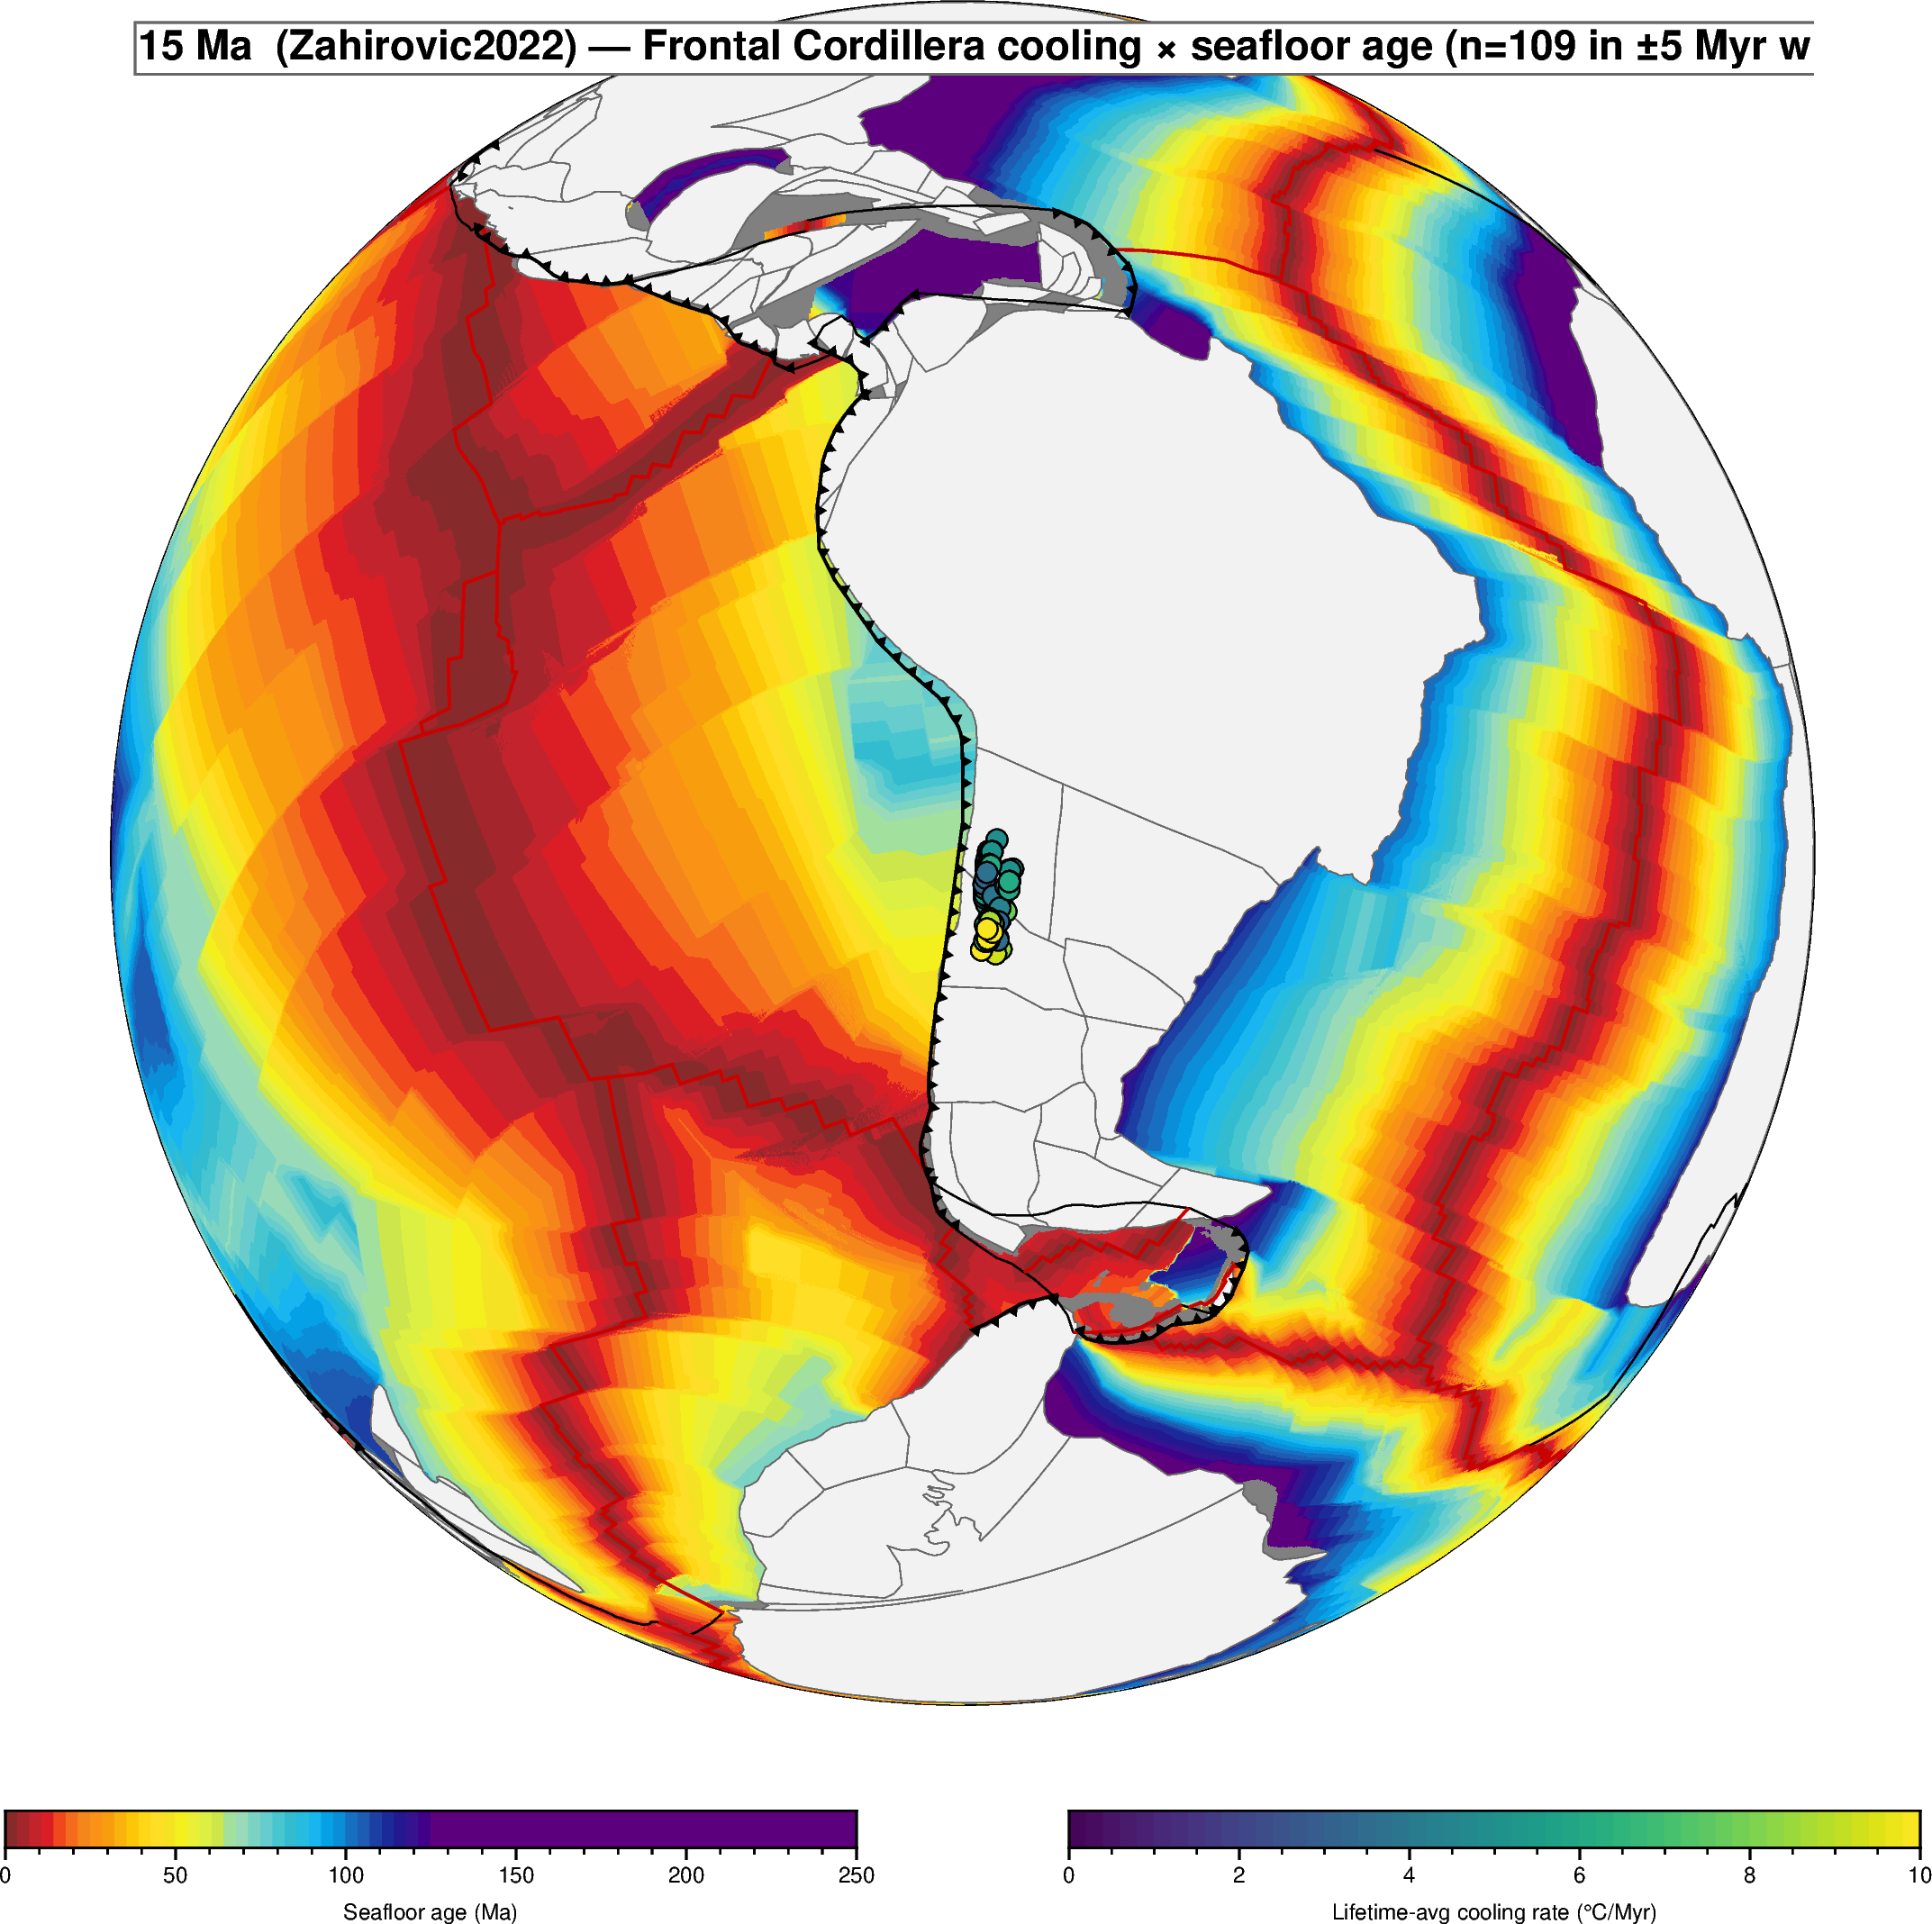

In [5]:
agegrid_da = xr.open_dataarray(
    model.get_raster("AgeGrids", time=float(RECONSTRUCTION_TIME))
)
fig_A = pygmt.Figure()
fig_A.basemap(region="d", projection=GLOBAL_PROJ, frame=["af"])
pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 250, 1], background="o")
fig_A.grdimage(agegrid_da, cmap=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_A, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig_A, pen="0.5p,black")
gplot.plot_ridges(fig_A, pen="0.8p,red3")
gplot.plot_trenches(fig_A, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_A, color="black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
               frame=["xa50f10+lSeafloor age (Ma)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.2], background="o")
fig_A.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.20c", pen="0.4p,black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
               frame=["xa2f0.5+lLifetime-avg cooling rate (@.C/Myr)"])
fig_A.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — Frontal Cordillera cooling × seafloor age (n={len(samples_now)} in ±{AGE_WINDOW_MYR:.0f} Myr window)",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="11p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_A.show(width=900)

### What this figure shows you

The cooling-rate dots are located **directly above** the Nazca-South America subduction trench (the prominent north-south band along the Pacific margin of South America). The young (warm) Nazca seafloor immediately offshore is being subducted under the South American margin at high convergence rates (5–10 cm/yr in the Miocene). This is the geometry that should produce the strongest possible cooling × convergence coupling — exactly the opposite case to T51 (AARS, where samples are located far from any active convergence).

## 4. Layer B — cooling rates × paleotopography (Frontal Cordillera Albers zoom, SW frame)

Following T51's rigorously frame-matched pattern: load Scotese & Wright 2018
via PMM, re-reconstruct samples through SW to the DEM's exact age, plot the
SW DEM with SW-reconstructed dots.

2026-06-27,17:02:03 - pmm - WARNING - The layer(Coastlines) was not found in model(scotese_and_wright2018).


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


  Layer B at pt_age=25 Ma: 50 samples reconstructed via SW (0 outside SW coverage)


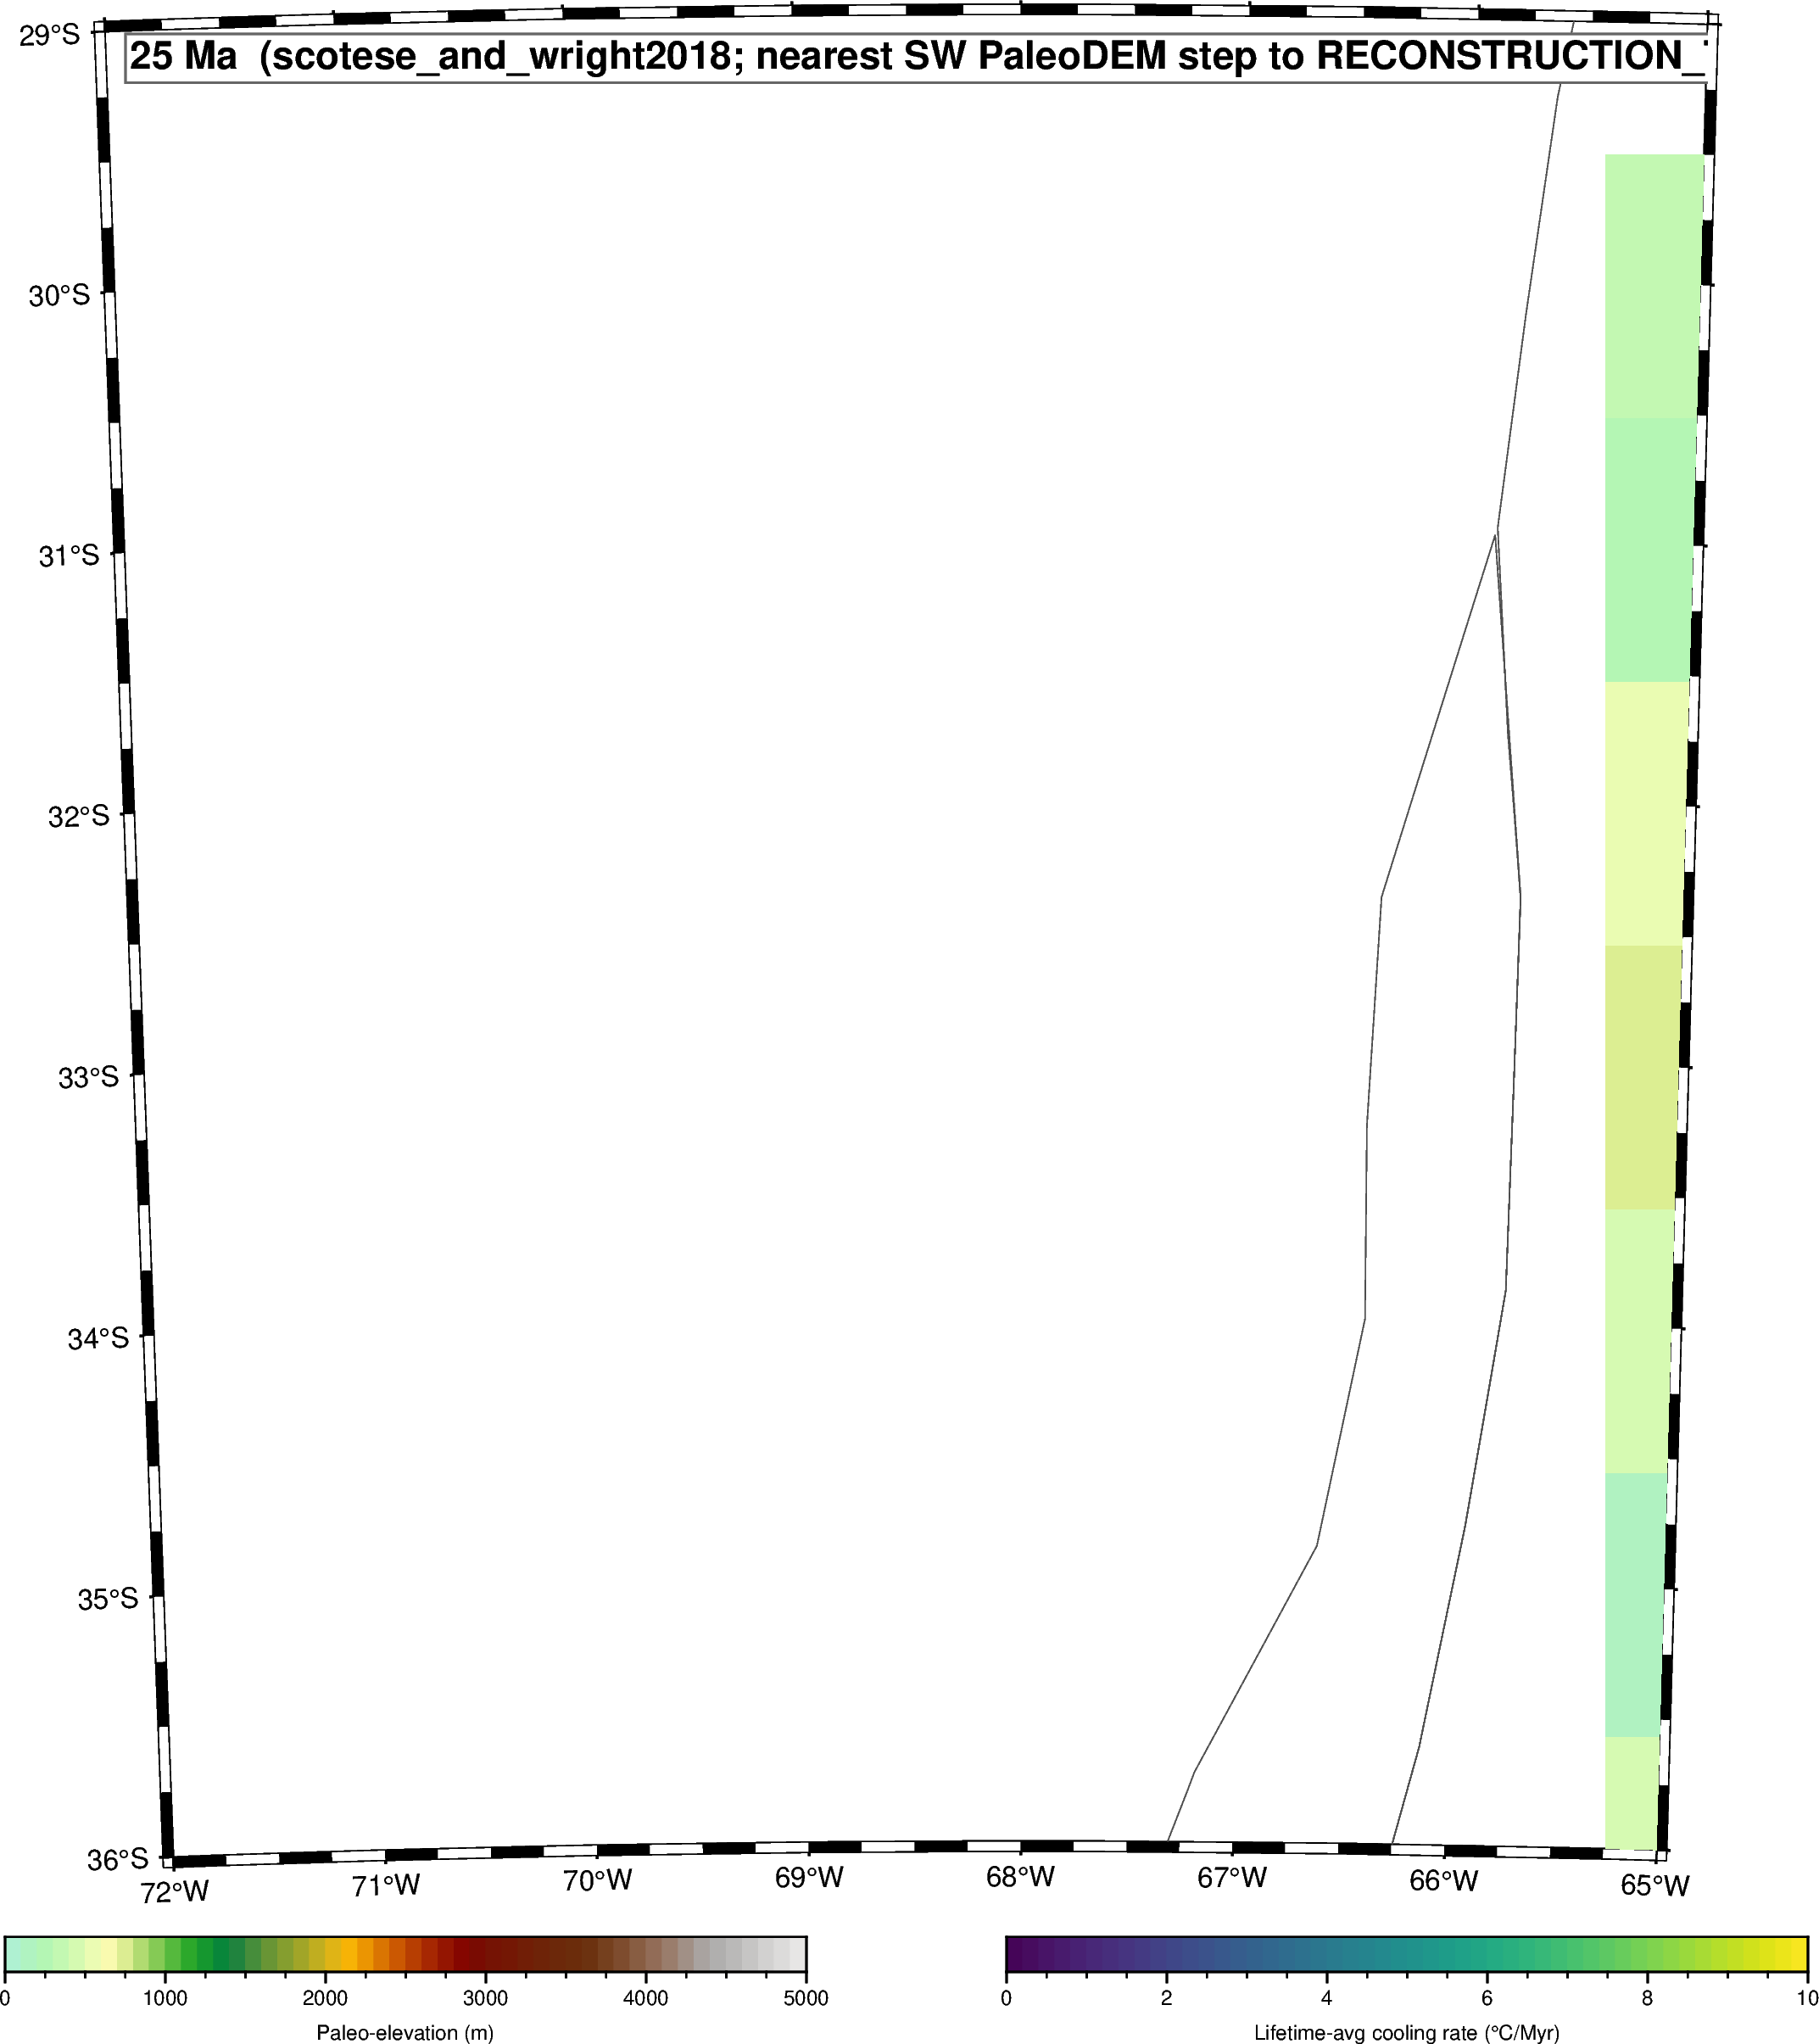

In [6]:
import re as _re
paleotopo_steps = sorted(
    int(_re.search(r"^(\d+)Ma_", p.name).group(1))
    for p in PALEODEM_DIR.glob("*Ma_corrected_SW.nc")
)
pt_age = min(paleotopo_steps, key=lambda a: abs(a - RECONSTRUCTION_TIME))
pt_path = PALEODEM_DIR / f"{pt_age}Ma_corrected_SW.nc"
pt_ds = xr.open_dataset(pt_path)
pt_da = pt_ds["M_corrected"] if "M_corrected" in pt_ds.data_vars else pt_ds["z"]
pt_land = pt_da.where(pt_da >= 0)

# SW plate-model stack (separate from the Z22 stack used elsewhere)
model_sw = pmm.get_model("scotese_and_wright2018", data_dir="./gplately_data")
recon_sw = gplately.PlateReconstruction(
    rotation_model=model_sw.get_rotation_model(),
    topology_features=model_sw.get_topologies() if hasattr(model_sw, "get_topologies") else None,
    static_polygons=model_sw.get_static_polygons(),
    anchor_plate_id=0,
)
try:
    coastlines_sw = model_sw.get_coastlines()
except Exception:
    coastlines_sw = None
gplot_sw = gplately.PlotTopologies(
    plate_reconstruction=recon_sw, coastlines=coastlines_sw,
    continents=model_sw.get_continental_polygons(), COBs=None,
    time=float(pt_age), plot_engine=gplately.PygmtPlotEngine(),
)

# Recompute the actively-cooling samples + reconstruct through SW AT pt_age
samples_sw_base = per_sample_cooling_at(pt_age, hist)
rlons_sw = np.full(len(samples_sw_base), np.nan)
rlats_sw = np.full(len(samples_sw_base), np.nan)
for i, (lon, lat) in enumerate(zip(samples_sw_base["lon"].to_numpy(float),
                                     samples_sw_base["lat"].to_numpy(float))):
    try:
        gpt = gplately.Points(recon_sw, [lon], [lat], anchor_plate_id=0)
        rl, rla = gpt.reconstruct(float(pt_age), return_array=True, anchor_plate_id=0)
        if len(rl) == 1 and np.isfinite(rl[0]) and np.isfinite(rla[0]):
            rlons_sw[i] = float(rl[0]); rlats_sw[i] = float(rla[0])
    except Exception:
        pass
samples_sw = samples_sw_base[["sample_name", "cooling_rate", "method"]].copy()
samples_sw["rlon_sw"] = rlons_sw; samples_sw["rlat_sw"] = rlats_sw
n_dropped = int(samples_sw[["rlon_sw","rlat_sw"]].isna().any(axis=1).sum())
samples_sw = samples_sw.dropna(subset=["rlon_sw", "rlat_sw"])
print(f"  Layer B at pt_age={pt_age} Ma: {len(samples_sw)} samples reconstructed via SW "
      f"({n_dropped} outside SW coverage)")

fig_B = pygmt.Figure()
fig_B.basemap(region=REGION_FRONTAL, projection=REGIONAL_PROJ, frame=["af", "WSne"])
pygmt.makecpt(cmap="dem4", series=[0, 5000, 100], background="o")
fig_B.grdimage(pt_land, cmap=True, nan_transparent=True)
gplot_sw.plot_continents(fig_B, fill=None, pen="0.3p,gray30")
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
               frame=["xa1000f250+lPaleo-elevation (m)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.2], background="o")
fig_B.plot(x=samples_sw["rlon_sw"], y=samples_sw["rlat_sw"],
           fill=samples_sw["cooling_rate"], cmap=True,
           style="c0.30c", pen="0.5p,black")
fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
               frame=["xa2f0.5+lLifetime-avg cooling rate (@.C/Myr)"])
fig_B.text(text=f"{pt_age:.0f} Ma  (scotese_and_wright2018; nearest SW PaleoDEM step to RECONSTRUCTION_TIME={RECONSTRUCTION_TIME:.0f} Ma)",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="11p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_B.show(width=900)

### What this figure shows you

The Frontal Cordillera at this snapshot is in mid-construction — the corrected SW paleo-DEM shows incipient Andean relief sitting above the Nazca trench. The bright viridis dots cluster in the actively-uplifting Frontal/Principal Cordillera belt; Howlett et al. (2025) interpret the rapid cooling pulse here as the *kinematic response* to high-flux Nazca subduction below.

## 5. Layer C — cooling rates × convergence rate (Nazca → South America subduction)

  Andean-margin subduction segments at 15 Ma: 61


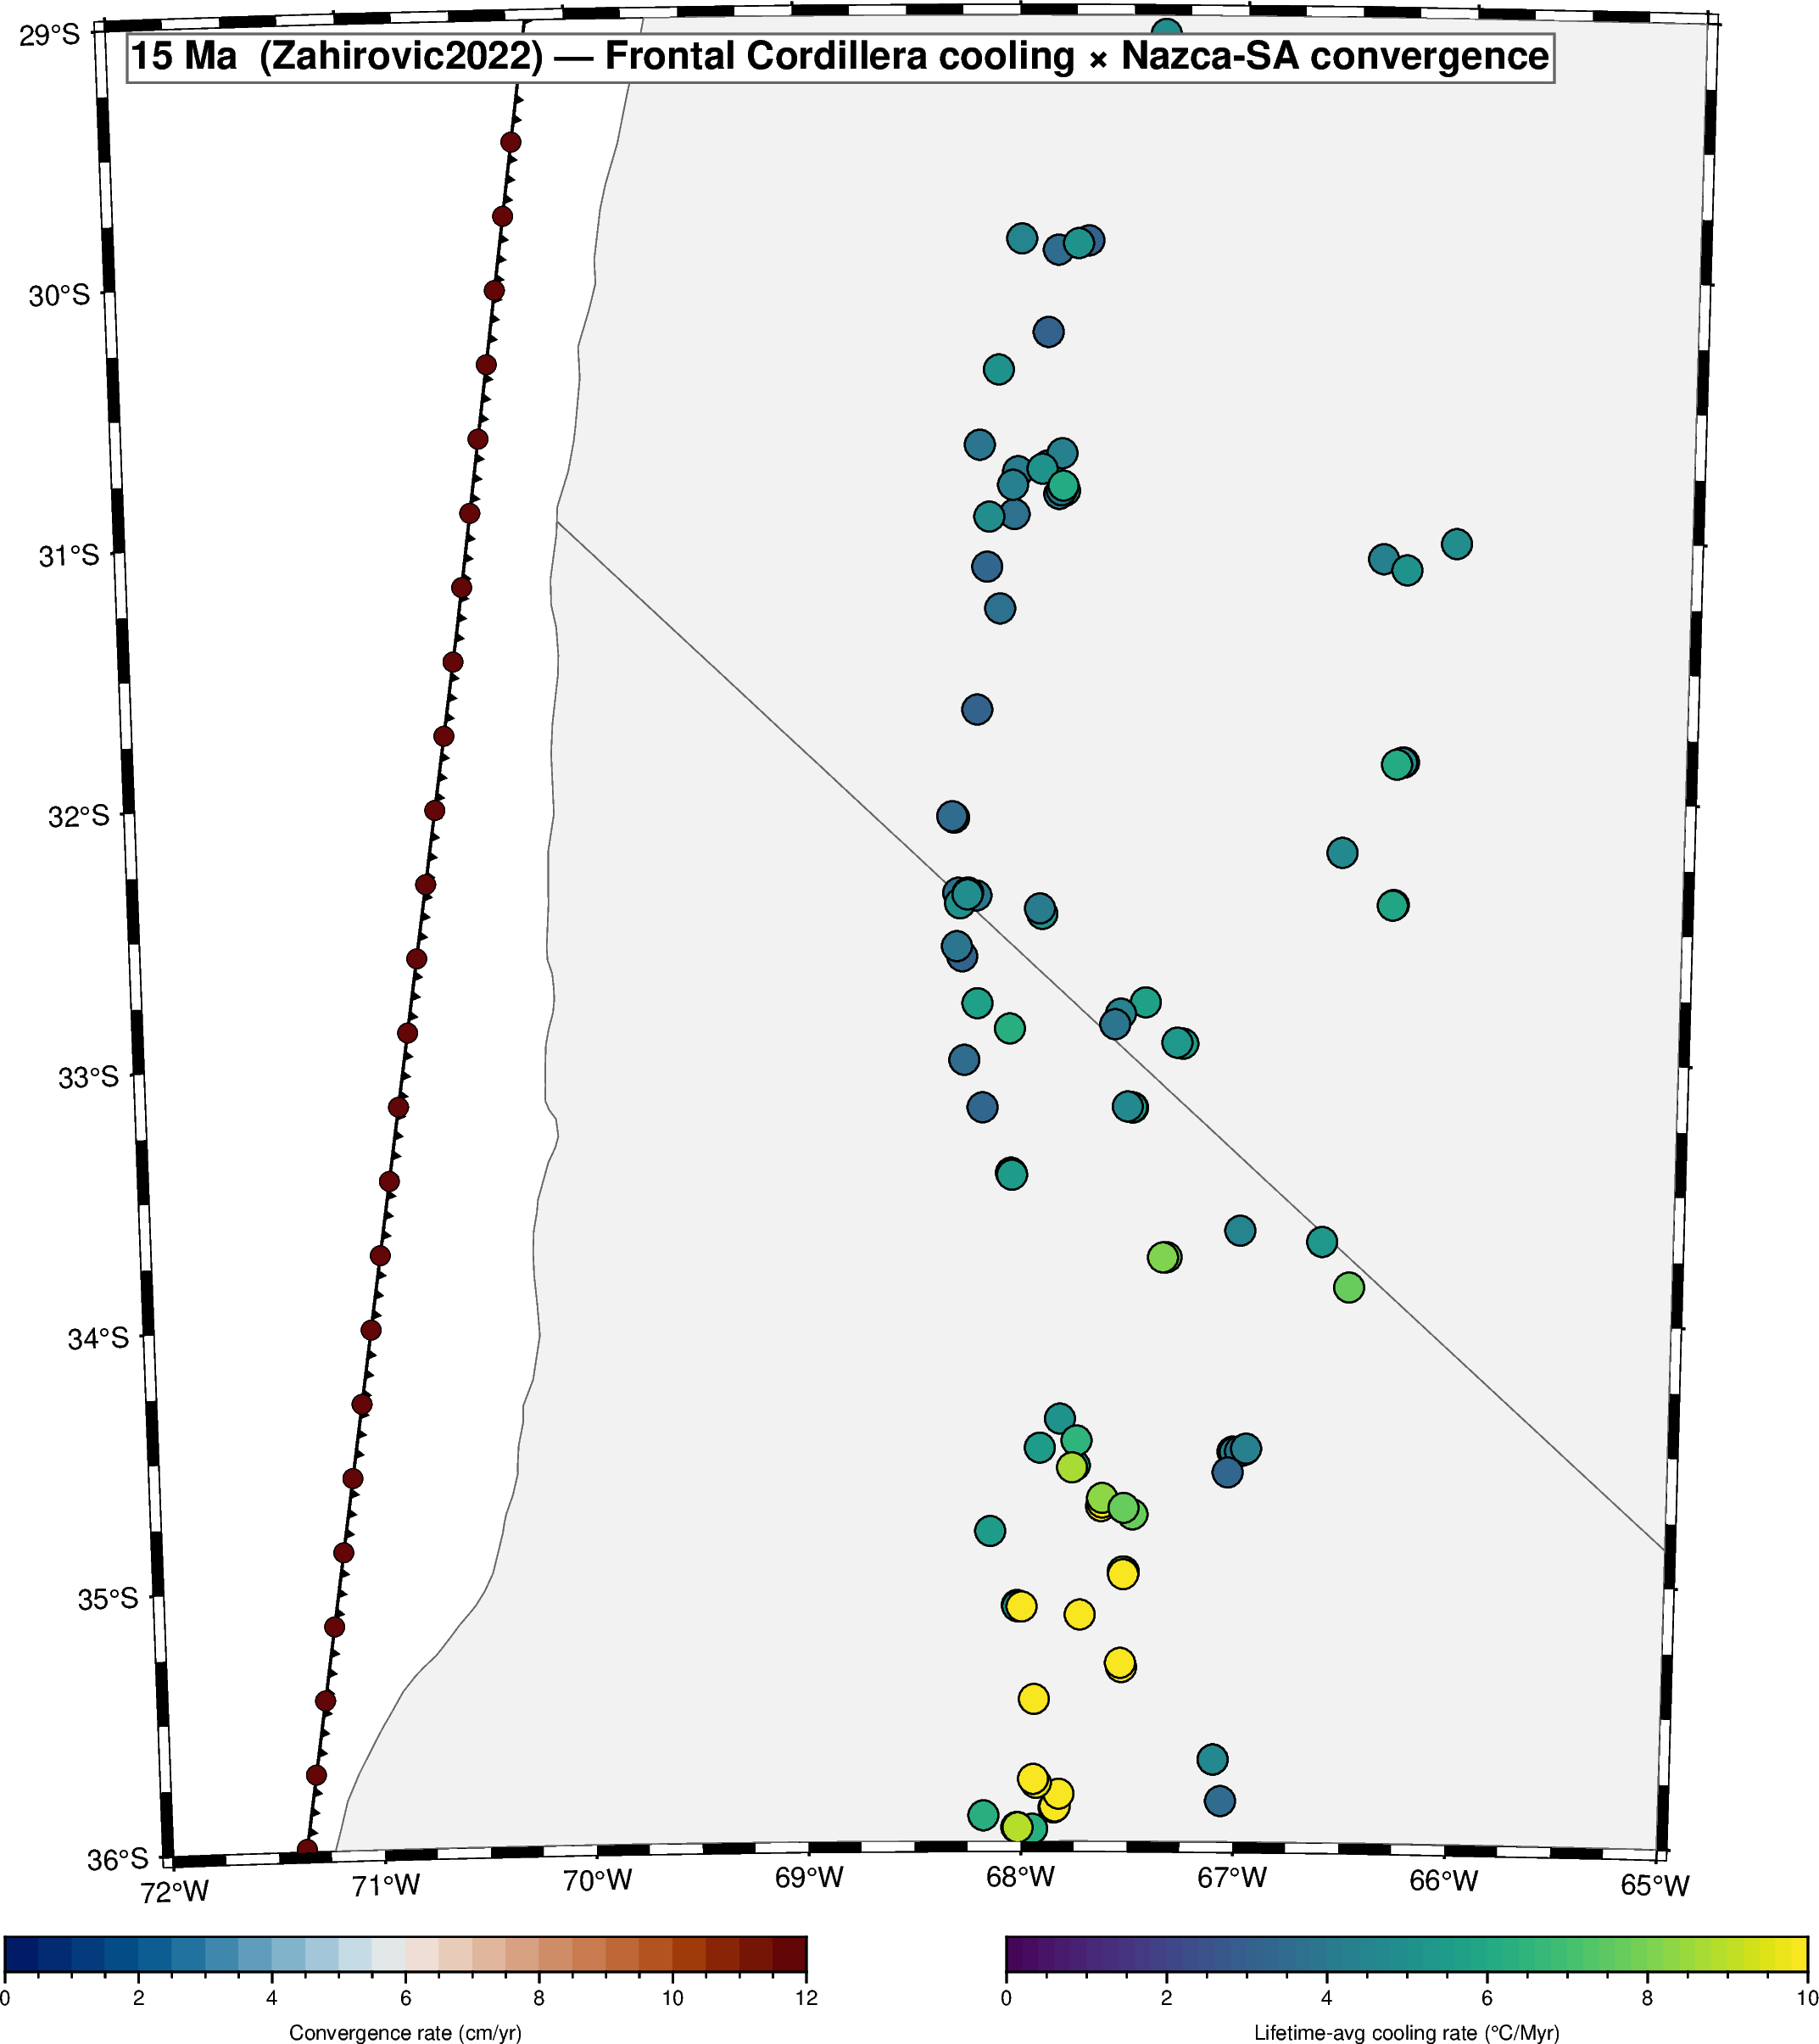

In [7]:
kin = recon.tessellate_subduction_zones(
    float(RECONSTRUCTION_TIME),
    tessellation_threshold_radians=TESS_THRESHOLD_RAD,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
kin_df = pd.DataFrame(kin, columns=[
    "lon", "lat", "conv_rate_cm_yr", "conv_obliquity_deg",
    "migr_rate_cm_yr", "migr_obliquity_deg",
    "segment_length_rad", "arc_normal_azimuth_deg",
    "subducting_plate_id", "overriding_plate_id",
])
in_box = ((kin_df["lon"] >= REGION_FRONTAL[0] - 5) &
           (kin_df["lon"] <= REGION_FRONTAL[1] + 5) &
           (kin_df["lat"] >= REGION_FRONTAL[2] - 5) &
           (kin_df["lat"] <= REGION_FRONTAL[3] + 5))
kin_box = kin_df.loc[in_box].copy()
kin_box = kin_box[kin_box["conv_rate_cm_yr"] >= 0]
print(f"  Andean-margin subduction segments at {RECONSTRUCTION_TIME:.0f} Ma: {len(kin_box):,}")

fig_C = pygmt.Figure()
fig_C.basemap(region=REGION_FRONTAL, projection=REGIONAL_PROJ, frame=["af", "WSne"])
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_C, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig_C, pen="0.5p,black")
gplot.plot_ridges(fig_C, pen="0.8p,red3")
gplot.plot_trenches(fig_C, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_C, color="black")
pygmt.makecpt(cmap="vik", series=[0, 12, 0.5], background="o")
fig_C.plot(x=kin_box["lon"], y=kin_box["lat"],
           fill=kin_box["conv_rate_cm_yr"], cmap=True,
           style="c0.20c", pen="0.2p,black")
fig_C.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/0.8c",
               frame=["xa2f0.5+lConvergence rate (cm/yr)"])
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.2], background="o")
fig_C.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.30c", pen="0.5p,black")
fig_C.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/0.8c",
               frame=["xa2f0.5+lLifetime-avg cooling rate (@.C/Myr)"])
fig_C.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — Frontal Cordillera cooling × Nazca-SA convergence",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="11p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig_C.show(width=900)

### What this figure shows you

Unlike T51's AARS case, here the cooling-rate dots are located *immediately above* the convergence-rate dots — the active Nazca trench is ~200 km west of the Frontal Cordillera. Fast convergence (red dots, ~7–10 cm/yr) is the contemporaneous tectonic driver. §6 quantifies the correlation.

## 6. Cross-variable correlations — cooling rate vs nearest-segment convergence rate, time-series

Same pipeline as T51 §6 — sweep ages, find each sample's nearest subduction
segment, compute Pearson r per age.

In [8]:
from scipy.spatial import cKDTree

def nearest_conv_rate(sample_lons, sample_lats, kin_df_age):
    if len(kin_df_age) == 0 or len(sample_lons) == 0:
        return np.full(len(sample_lons), np.nan)
    def to_xyz(lons, lats):
        lats_r = np.radians(lats); lons_r = np.radians(lons)
        return np.column_stack([np.cos(lats_r)*np.cos(lons_r),
                                  np.cos(lats_r)*np.sin(lons_r),
                                  np.sin(lats_r)])
    kin_xyz = to_xyz(kin_df_age["lon"].values, kin_df_age["lat"].values)
    samp_xyz = to_xyz(np.asarray(sample_lons), np.asarray(sample_lats))
    _, idx = cKDTree(kin_xyz).query(samp_xyz, k=1)
    return kin_df_age["conv_rate_cm_yr"].values[idx]

def build_master_for_age(age_ma: float):
    samp = per_sample_cooling_at(age_ma, hist)
    if samp.empty: return None
    gpts_a = gplately.Points(recon, samp["lon"].to_numpy(float),
                              samp["lat"].to_numpy(float),
                              anchor_plate_id=ANCHOR_PLATE_ID)
    rl_a, ra_a = gpts_a.reconstruct(float(age_ma),
                                     return_array=True,
                                     anchor_plate_id=ANCHOR_PLATE_ID)
    samp = samp.assign(rlon=rl_a, rlat=ra_a).dropna(subset=["rlon","rlat"]).copy()
    kin_a = pd.DataFrame(
        recon.tessellate_subduction_zones(float(age_ma),
                                           tessellation_threshold_radians=TESS_THRESHOLD_RAD,
                                           anchor_plate_id=ANCHOR_PLATE_ID),
        columns=["lon","lat","conv_rate_cm_yr","conv_obliquity_deg",
                 "migr_rate_cm_yr","migr_obliquity_deg",
                 "segment_length_rad","arc_normal_azimuth_deg",
                 "subducting_plate_id","overriding_plate_id"],
    )
    samp["nearest_conv_rate_cm_yr"] = nearest_conv_rate(
        samp["rlon"].values, samp["rlat"].values, kin_a)
    samp["age_Ma"] = float(age_ma)
    return samp

def master_path_for(age_ma): return MASTER_PARQUET_DIR / f"thermochron_master_{int(age_ma):03d}Ma.parquet"

n_built = n_cached = 0
for age in AGES_MA:
    p = master_path_for(age)
    if p.exists(): n_cached += 1; continue
    df = build_master_for_age(float(age))
    if df is None or df.empty: continue
    df.to_parquet(p); n_built += 1
print(f"  ✓ built {n_built} new parquet(s); {n_cached} already cached")

  ✓ built 0 new parquet(s); 13 already cached


  filtered out 21 rows with negative convergence rate (model artefact)
  pooled: 761 (sample, age) pairs across 12 ages


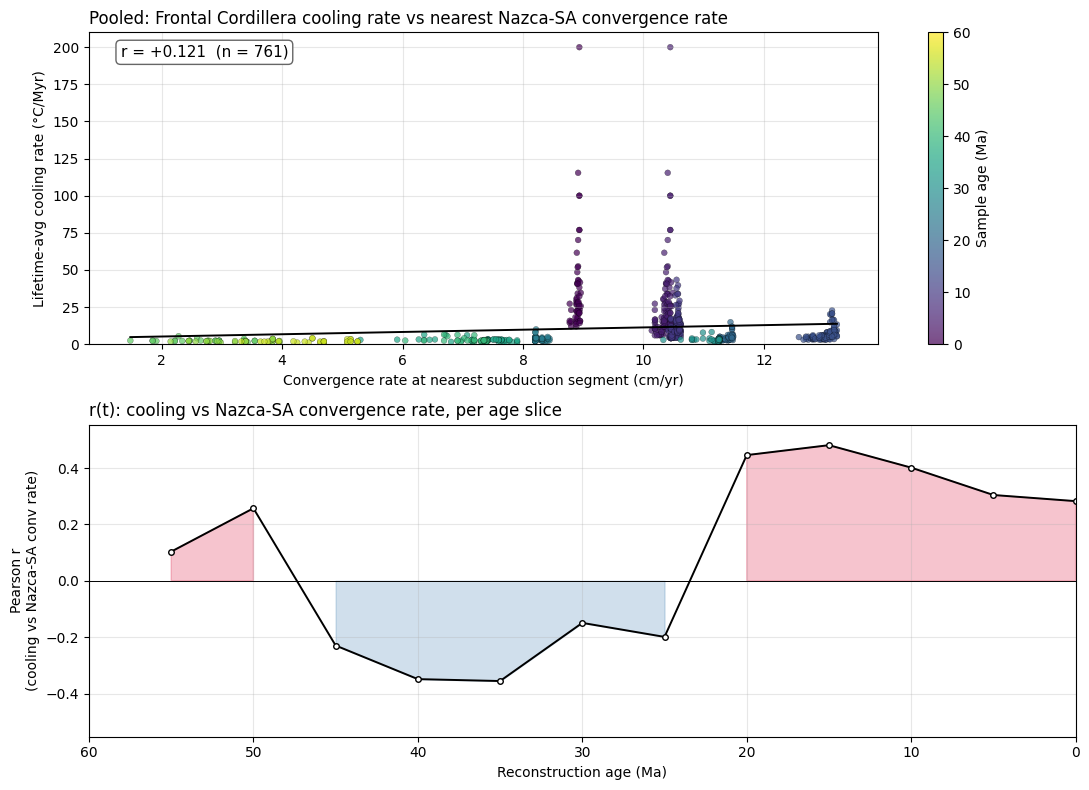

In [9]:
frames = [pd.read_parquet(master_path_for(a)) for a in AGES_MA if master_path_for(a).exists()]
pool = pd.concat(frames, ignore_index=True)
n_neg = int((pool["nearest_conv_rate_cm_yr"] < 0).sum())
if n_neg > 0:
    print(f"  filtered out {n_neg} rows with negative convergence rate (model artefact)")
    pool = pool[pool["nearest_conv_rate_cm_yr"] >= 0].reset_index(drop=True)
print(f"  pooled: {len(pool):,} (sample, age) pairs across {pool['age_Ma'].nunique()} ages")

def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.nan, int(m.sum())
    x, y = x[m], y[m]
    return float(np.corrcoef(x, y)[0, 1]), int(len(x))

rows = []
for age, sub in pool.groupby("age_Ma"):
    r, n = pearson_r(sub["nearest_conv_rate_cm_yr"].to_numpy(float),
                      sub["cooling_rate"].to_numpy(float))
    rows.append({"age_Ma": age, "r_cool_vs_conv": r, "n": n})
r_by_age = pd.DataFrame(rows).sort_values("age_Ma")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
df = pool.dropna(subset=["nearest_conv_rate_cm_yr", "cooling_rate"])
age_norm = Normalize(AGE_MIN_MA, AGE_MAX_MA)
sc = ax1.scatter(df["nearest_conv_rate_cm_yr"], df["cooling_rate"],
                  c=df["age_Ma"], cmap="viridis", norm=age_norm,
                  s=18, edgecolor="black", linewidth=0.2, alpha=0.7)
if len(df) > 1:
    slope, intercept = np.polyfit(df["nearest_conv_rate_cm_yr"], df["cooling_rate"], 1)
    xline = np.linspace(df["nearest_conv_rate_cm_yr"].min(),
                         df["nearest_conv_rate_cm_yr"].max(), 100)
    ax1.plot(xline, slope*xline + intercept, color="black", lw=1.4)
r_all, n_all = pearson_r(df["nearest_conv_rate_cm_yr"].values, df["cooling_rate"].values)
ax1.text(0.04, 0.96, f"r = {r_all:+.3f}  (n = {n_all:,})",
         transform=ax1.transAxes, va="top", ha="left", fontsize=11,
         bbox=dict(facecolor="white", edgecolor="0.40", boxstyle="round,pad=0.3"))
ax1.set_xlabel("Convergence rate at nearest subduction segment (cm/yr)")
ax1.set_ylabel("Lifetime-avg cooling rate (°C/Myr)")
x_pad = (df["nearest_conv_rate_cm_yr"].max() - df["nearest_conv_rate_cm_yr"].min()) * 0.05 + 0.1
ax1.set_xlim(df["nearest_conv_rate_cm_yr"].min() - x_pad,
             df["nearest_conv_rate_cm_yr"].max() + x_pad)
ax1.set_ylim(0, max(df["cooling_rate"].max() * 1.05, 1.0))
ax1.grid(alpha=0.3)
ax1.set_title("Pooled: Frontal Cordillera cooling rate vs nearest Nazca-SA convergence rate", loc="left")
plt.colorbar(sc, ax=ax1, label="Sample age (Ma)")

valid = r_by_age.dropna(subset=["r_cool_vs_conv"])
ax2.axhline(0, color="black", lw=0.7)
ax2.fill_between(valid["age_Ma"], valid["r_cool_vs_conv"], 0,
                  where=(valid["r_cool_vs_conv"] > 0), alpha=0.25, color="crimson")
ax2.fill_between(valid["age_Ma"], valid["r_cool_vs_conv"], 0,
                  where=(valid["r_cool_vs_conv"] < 0), alpha=0.25, color="steelblue")
ax2.plot(valid["age_Ma"], valid["r_cool_vs_conv"], color="black", lw=1.4,
         marker="o", markersize=4, markerfacecolor="white")
ax2.set_ylabel("Pearson r\n(cooling vs Nazca-SA conv rate)")
_r_abs = max(0.2, max(abs(valid["r_cool_vs_conv"].min()),
                       abs(valid["r_cool_vs_conv"].max())))
ax2.set_ylim(-_r_abs * 1.15, _r_abs * 1.15)
ax2.set_xlim(AGE_MAX_MA, AGE_MIN_MA)
ax2.set_xlabel("Reconstruction age (Ma)")
ax2.grid(alpha=0.3)
ax2.set_title("r(t): cooling vs Nazca-SA convergence rate, per age slice", loc="left")
fig.tight_layout(); plt.show()

### What this figure shows you — comparison with T51

For the Frontal Cordillera samples (which are all located ~200 km from the Nazca trench), the *nearest-segment* convergence rate is essentially a single value at any given age — what varies is the **temporal evolution** of Nazca-SA convergence. The Pearson r vs age time-series therefore primarily reflects the temporal coincidence between Andean cooling pulses and convergence-rate maxima — strongest when Andean fast-cooling phases align with the Miocene convergence ramp-up (~20-15 Ma).

Compare with T51: AARS samples were geographically far from any active subduction and the Pearson r was weak across the Phanerozoic. Here the samples are directly above an active margin, and the r-vs-time pattern instead tracks the *Miocene tectonic transition*. **Caveat on metric**: T52's cooling-rate is a lifetime-average proxy (T_closure / age), not an instantaneous TempDiff cooling rate as in T51 — so the absolute *r* values aren't directly comparable, but the temporal shape of r(t) carries the same kind of information.

## Extend this

### Maps at other snapshot ages — getting more SW PaleoDEM grids

Bundled `data/paleotopo_scotese/corrected_SW/` ships 16 ages covering 0–500 Ma at 25-Myr cadence. For the full 5-Myr-cadence corrected SW set (109 NCs, 0–540 Ma), clone https://github.com/EarthByte/paleotopo-data-assimilation and symlink it at `external/Paleotopo_data_assimilation/`. For the original (uncorrected) Scotese & Wright 2018 PaleoDEMs at 5-Myr cadence, see https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/.

- **Per-method instantaneous cooling rates from QTQt outputs.** The Howlett 2025 Zenodo deposit also ships QTQt time-temperature model outputs in `Mercedario-Tect-Dataset_S2.zip` for the 7 samples Howlett's team modelled in detail. Drop that zip alongside S4, parse out the per-sample t-T paths, and replace the lifetime-average proxy with proper TempDiff cooling rates over short time windows (the T51 schema). Spatial coverage will collapse from 577 samples to 7, but the per-sample resolution gains.
- **Dynamic-topography overlay (T48 template).** South American DT is non-trivial (Salles et al., Flament et al., Faccenna et al. on Nazca-slab-driven dynamic topography). Mirror T48's Layer B + 5-snapshot loop: compute ΔDT/Δt in plate frame (gmcm9), rotate to mantle frame via T23's helper, sample at the Frontal-Cordillera positions.
- **Direct slab-flat / slab-steep contrast.** The 32°S Pampean flat-slab segment is located immediately south of the Andean-volcanic-arc / Pampean flat-slab transition. Compare cooling rates in the flat-slab segment with cooling rates further south where subduction is steeper.
- **Cross-reference T49's fault-proximity workflow.** South American active-fault databases (e.g. the SARA project compilation) provide candidate reactivation structures — rerun T49's GEM+AFEAD fault-proximity test for the Frontal Cordillera with a South-America-restricted fault subset.
- **Method-aware analysis.** The dataset mixes AHe / AFT / ZHe / ZFT — different closure temperatures sample different depths. Split the §6 r(t) analysis by method to see whether different temperature windows track convergence differently.

## References

- Howlett, C., Carrapa, B., Reiners, P., DeCelles, P. & Constenius, K.N. (2025). Miocene construction of the High Andes recorded by exhumation of the Frontal Cordillera, La Ramada Massif of western Argentina (32°S). *Tectonics* 44, e2024TC008433. https://doi.org/10.1029/2024TC008433
- Howlett, C. (2025). *Supporting datasets for Howlett et al., Miocene construction of the High Andes recorded by exhumation of the Frontal Cordillera, La Ramada Massif of western Argentina (32°S)* [Dataset]. *Zenodo*. https://doi.org/10.5281/zenodo.11152585 (CC-BY 4.0)
- Reiners, P.W. & Brandon, M.T. (2006). Using thermochronology to understand orogenic erosion. *Annual Review of Earth and Planetary Sciences* 34, 419–466. https://doi.org/10.1146/annurev.earth.34.031405.125202 — source for the nominal AHe/AFT/ZHe/ZFT closure-temperature values used here.
- Boone, S.C., Glorie, S., Zahirovic, S., Nixon, A., Meeuws, F. & Kohlmann, F. (2025). Deciphering mantle, tectonic and climatic drivers of exhumation. *Communications Earth & Environment* 6, 1015. https://doi.org/10.1038/s43247-025-03005-6 — the methodological template (Central Asia ThermoPlates workflow) that the suite's cooling-rate × kinematic-context notebooks port to Python.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515